## Video Link- https://drive.google.com/file/d/1x0JDz-LhEpWzvEqfum-Ezv4E0sZxhEgF/view?usp=sharing

## Github Link- https://github.com/mohit-codes-21/QuickBites/tree/main/A2

## Introduction

In this project, we implement a lightweight database indexing engine using a **B+ Tree** and compare it with a **Brute Force** approach.

The goal is to analyze how indexing improves performance for database operations such as:
- Insert
- Search
- Range Query
- Delete

The B+ Tree is widely used in databases because it provides efficient lookup and range queries, while brute force performs linear scans.

This report evaluates both approaches using automated benchmarking across multiple dataset sizes.

## Problem Statement

Efficient data retrieval is critical for database systems.

Without indexing or with linear/flat indexing:
- Search requires scanning all records → O(n)
- Range queries are expensive
- Performance degrades as dataset grows

To address this, we implement:
- A **B+ Tree index**
- A **Brute Force baseline**
- A **Performance Analyzer** to compare both

The objective is to demonstrate how indexing improves scalability.

## Implementation Overview

### Data Model
We have taken our schema while keeping in mind our project topic of QuickBites(Food Delievery System)
Each record contains:
- customerID (key)
- loyaltyTier
- membershipDiscount
- cartTotalAmount
- membershipDueDate
- membership

The `customerID` is used as the indexing key.

---

### B+ Tree

The B+ Tree supports:
- Insert
- Search
- Range Query
- Delete

Key properties:
- Balanced tree
- Logarithmic search time
- Linked leaf nodes for efficient range queries

---

### Brute Force

The brute force structure:
- Stores data in a list
- Performs linear scan for all operations

This acts as a baseline for comparison.

---

### Performance Analyzer

The analyzer benchmarks:
- Insert time
- Search time
- Range query time
- Delete time
- Mixed workload(empty)
- Mixed workload(populated)
- Memory usage

Across multiple dataset sizes.

## Time Complexity Analysis

The performance differences observed in the benchmark can be explained using theoretical time complexities of the two approaches.

---

### B+ Tree Complexity

| Operation      | Time Complexity |
|----------------|----------------|
| Insert         | O(log n)       |
| Search         | O(log n)       |
| Delete         | O(log n)       |
| Range Query    | O(log n + k)   |

Where:
- `n` = number of records
- `k` = number of elements in the range

**Explanation:**
- The tree remains balanced, so height is logarithmic.
- Search follows a root-to-leaf path → O(log n)
- Range queries are efficient because leaf nodes are linked.

---

### Brute Force Complexity

| Operation      | Time Complexity |
|----------------|----------------|
| Insert         | O(n)           |
| Search         | O(n)           |
| Delete         | O(n)           |
| Range Query    | O(n)           |

**Explanation:**
- Data is stored in a list
- Insert requires scanning to check if the key already exists
- Search and delete require full scans
- Range queries also scan all elements

---

### Comparison Summary

| Operation      | B+ Tree        | Brute Force |
|----------------|---------------|------------|
| Insert         | O(log n)      | O(n)       |
| Search         | O(log n)      | O(n)       |
| Delete         | O(log n)      | O(n)       |
| Range Query    | O(log n + k)  | O(n)       |

---

### Relation to Experimental Results

The benchmark results align with theoretical expectations:

- Brute force operations scale linearly, making them slow for large datasets
- B+ Tree operations scale logarithmically, leading to better performance
- Insert in brute force becomes expensive due to duplicate checking
- Range queries benefit significantly from B+ Tree structure

# 📘 B+ Tree Implementation Details (Operation Flow)

## 1. Search Operation

- `search(key)` calls `_find_leaf(key)` to reach the correct leaf node.
- `_find_leaf` traverses from root using binary search (`bisect_right`) at each level.
- Once at the leaf, binary search (`bisect_left`) is used to check if the key exists.
- If found → return value, else → return `None`.

---

## 2. Insertion Operation

- `insert(key, value)` calls `_insert_non_full(root, key, value)`.

- `_insert_non_full`:
  - If leaf → insert key in sorted order using binary search.
  - If internal → find correct child using `bisect_right` and recurse.

- After insertion:
  - If child overflows → `_split_child(parent, index)` is called.

- `_split_child`:
  - Splits node into two.
  - For leaf → maintain `next` pointer and promote first key of new node.
  - For internal → promote middle key.

- If root overflows → new root is created (tree height increases).

---

## 3. Deletion Operation

- `delete(key)` calls `_delete(root, key)`.

- `_delete`:
  - If leaf → remove key using binary search.
  - If internal → recurse to correct child.

- After deletion:
  - If node underflows → `_fill_child(parent, index)` is called.

- `_fill_child` tries:
  1. `_borrow_from_prev`
  2. `_borrow_from_next`
  3. `_merge` (if borrowing not possible)

- If root becomes empty → replace with its child.

---

## 4. Update Operation

- `update(key, value)`:
  - Calls `_find_leaf(key)`
  - Uses binary search to locate key
  - Updates value if found

---

## 5. Range Query

- `range_query(start, end)`:
  - Calls `_find_leaf(start)`
  - Iterates keys in leaf
  - Moves across leaves using `next` pointer
  - Stops when keys exceed `end`

---

## 6. Full Scan

- `get_all()`:
  - Goes to leftmost leaf
  - Traverses all leaves using `next`
  - Returns all records in sorted order

## Simple Testing

In [6]:
from database.table import Table

# Create table
table = Table(
    name="test",
    schema={"customerID": int, "name": str, "age": int},
    order=4,
    search_key="customerID",
    index_type="bplustree"
)

# Insert 10 records
records = [
    {"customerID": 10, "name": "Alice",   "age": 30},
    {"customerID": 20, "name": "Bob",     "age": 25},
    {"customerID": 30, "name": "Charlie", "age": 35},
    {"customerID": 40, "name": "Diana",   "age": 28},
    {"customerID": 50, "name": "Eve",     "age": 22},
    {"customerID": 60, "name": "Frank",   "age": 45},
    {"customerID": 70, "name": "Grace",   "age": 31},
    {"customerID": 80, "name": "Hank",    "age": 27},
    {"customerID": 90, "name": "Ivy",     "age": 33},
    {"customerID": 100,"name": "Jack",    "age": 29},
]

for r in records:
    table.insert(r)

# Display all
print("=== ALL RECORDS ===")
for r in table.get_all():
    print(r)

# Search
print("\n=== SEARCH customerID=50 ===")
print(table.get(50))

# Delete
table.delete(50)
print("\n=== AFTER DELETE customerID=50 ===")
for r in table.get_all():
    print(r)

# Search deleted
print("\n=== SEARCH customerID=50 (should be None) ===")
print(table.get(50))

# Range query
print("\n=== RANGE QUERY 20 to 70 ===")
for r in table.range_query(20, 70):
    print(r)

=== ALL RECORDS ===
{'customerID': 10, 'name': 'Alice', 'age': 30}
{'customerID': 20, 'name': 'Bob', 'age': 25}
{'customerID': 30, 'name': 'Charlie', 'age': 35}
{'customerID': 40, 'name': 'Diana', 'age': 28}
{'customerID': 50, 'name': 'Eve', 'age': 22}
{'customerID': 60, 'name': 'Frank', 'age': 45}
{'customerID': 70, 'name': 'Grace', 'age': 31}
{'customerID': 80, 'name': 'Hank', 'age': 27}
{'customerID': 90, 'name': 'Ivy', 'age': 33}
{'customerID': 100, 'name': 'Jack', 'age': 29}

=== SEARCH customerID=50 ===
{'customerID': 50, 'name': 'Eve', 'age': 22}

=== AFTER DELETE customerID=50 ===
{'customerID': 10, 'name': 'Alice', 'age': 30}
{'customerID': 20, 'name': 'Bob', 'age': 25}
{'customerID': 30, 'name': 'Charlie', 'age': 35}
{'customerID': 40, 'name': 'Diana', 'age': 28}
{'customerID': 60, 'name': 'Frank', 'age': 45}
{'customerID': 70, 'name': 'Grace', 'age': 31}
{'customerID': 80, 'name': 'Hank', 'age': 27}
{'customerID': 90, 'name': 'Ivy', 'age': 33}
{'customerID': 100, 'name': 'Ja

## Performance Analysis and Benchmarking

In [ ]:
import time
import random
import tracemalloc
import matplotlib.pyplot as plt

from database.bplustree import BPlusTree
from database.table import Table
from database.db_manager import DatabaseManager
from database.bruteforce import BruteForceDB

random.seed(42)

In [2]:
import os
import time
import sys
import random
from statistics import mean
from decimal import Decimal
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [ ]:
import time
import random
import sys
from decimal import Decimal
from datetime import datetime, timedelta
import matplotlib.pyplot as plt


class PerformanceAnalyzer:
    def __init__(self, dataset_sizes=None, trials=3, order=100, seed=42, key_domain=10_000_000):
        if dataset_sizes is None:
            self.dataset_sizes = [1000, 5000, 10000, 25000, 50000]
        else:
            self.dataset_sizes = dataset_sizes
            
        self.trials = trials
        self.order = order
        self.key_domain = key_domain
        self.rng = random.Random(seed)
        
        self.schema = {
            "customerID": int,
            "loyaltyTier": int,
            "membershipDiscount": int,
            "cartTotalAmount": float,
            "membershipDueDate": int,
            "membership": bool,
        }
        
        self.results = {
            "insert": {"bplustree": [], "bruteforce": []},
            "search": {"bplustree": [], "bruteforce": []},
            "range_query": {"bplustree": [], "bruteforce": []},
            "delete": {"bplustree": [], "bruteforce": []},
            "mixed_populated": {"bplustree": [], "bruteforce": []},
            "mixed_empty": {"bplustree": [], "bruteforce": []},
            "memory": {"bplustree": [], "bruteforce": []},
        }

    def _make_record(self, customer_id):
        return {
            "customerID": customer_id,
            "loyaltyTier": self.rng.randint(1, 5),
            "membershipDiscount": self.rng.randint(0, 100),
            "cartTotalAmount": self.rng.uniform(0, 100000),
            "membershipDueDate": self.rng.randint(0, 3650),
            "membership": self.rng.choice([True, False]),
        }

    def _generate_unique_keys(self, n):
        return self.rng.sample(range(1, self.key_domain), n)

    def _generate_absent_keys(self, n):
        base = self.key_domain + 1
        return self.rng.sample(range(base, base + self.key_domain), n)

    def _create_structures(self):
        table_bt = Table(
            name="Cust_BT",
            schema=self.schema, 
            order=self.order, 
            search_key="customerID", 
            index_type="bplustree"
        )
        table_bf = Table(
            name="Cust_BF", 
            schema=self.schema, 
            order=self.order, 
            search_key="customerID", 
            index_type="bruteforce"
        )
        return table_bt, table_bf

    def _estimate_memory(self, obj):
        seen = set()
        stack = [obj]
        total_size = 0
        while stack:
            o = stack.pop()
            oid = id(o)
            if oid in seen: continue
            seen.add(oid)
            total_size += sys.getsizeof(o)
            if isinstance(o, dict):
                for k, v in o.items():
                    stack.append(k)
                    stack.append(v)
            elif isinstance(o, (list, tuple, set, frozenset)):
                for item in o:
                    stack.append(item)
            elif hasattr(o, "__dict__"):
                stack.append(vars(o))
        return total_size

    def _benchmark_insert(self, keys, records):
        table_bt, table_bf = self._create_structures()

        start = time.perf_counter()
        for key in keys:
            table_bt.insert(records[key])
        bplus_time = time.perf_counter() - start

        start = time.perf_counter()
        for key in keys:
            table_bf.insert(records[key])
        brute_time = time.perf_counter() - start

        return bplus_time, brute_time

    def _benchmark_search(self, keys, records):
        table_bt, table_bf = self._create_structures()
        n = len(keys)
        
        for key in keys:
            table_bt.insert(records[key])
            table_bf.insert(records[key])

        num_queries = max(10, n // 10)
        present_queries = self.rng.sample(keys, num_queries // 2)
        absent_queries = self._generate_absent_keys(num_queries - len(present_queries))
        queries = present_queries + absent_queries
        self.rng.shuffle(queries)

        start = time.perf_counter()
        for q in queries:
            table_bt.get(q)
        bplus_time = time.perf_counter() - start

        start = time.perf_counter()
        for q in queries:
            table_bf.get(q)
        brute_time = time.perf_counter() - start

        return bplus_time, brute_time

    def _benchmark_range_query(self, keys, records):
        table_bt, table_bf = self._create_structures()
        n = len(keys)
        
        for key in keys:
            table_bt.insert(records[key])
            table_bf.insert(records[key])

        num_queries = max(10, n // 20)
        width = self.key_domain // 1000 
        queries = [(left, left + self.rng.randint(0, width)) for left in [self.rng.randint(1, self.key_domain - width - 1) for _ in range(num_queries)]]

        start = time.perf_counter()
        for left, right in queries:
            table_bt.range_query(left, right)
        bplus_time = time.perf_counter() - start

        start = time.perf_counter()
        for left, right in queries:
            table_bf.range_query(left, right)
        brute_time = time.perf_counter() - start

        return bplus_time, brute_time

    def _benchmark_delete(self, keys, records):
        table_bt, table_bf = self._create_structures()
        n = len(keys)

        for key in keys:
            table_bt.insert(records[key])
            table_bf.insert(records[key])

        num_to_delete = max(10, n // 10)
        delete_keys = self.rng.sample(keys, num_to_delete)

        start = time.perf_counter()
        for key in delete_keys:
            table_bt.delete(key)
        bplus_time = time.perf_counter() - start

        start = time.perf_counter()
        for key in delete_keys:
            table_bf.delete(key)
        brute_time = time.perf_counter() - start

        return bplus_time, brute_time

    def _generate_mixed_ops(self, initial_pool, num_ops, is_empty_start=False):
        available = list(initial_pool)
        present = []
        operations = []

        for _ in range(num_ops):
            if is_empty_start and len(present) < (num_ops // 4):
                op = "insert"
            else:
                op = self.rng.choice(["insert", "search", "delete"])
            
            if op == "insert" and not available: op = "search" if present else "delete"
            if op == "delete" and not present: op = "insert" if available else "search"
            
            if op == "insert":
                key = available.pop()
                present.append(key)
                operations.append(("insert", key, self._make_record(key)))
            elif op == "search":
                key = self.rng.choice(present) if (present and self.rng.random() < 0.7) else (self.rng.choice(available) if available else self.rng.choice(present))
                operations.append(("search", key, None))
            elif op == "delete":
                key = present.pop(self.rng.randrange(len(present)))
                operations.append(("delete", key, None))
                
        return operations

    def _benchmark_mixed_populated(self, keys, records):
        table_bt, table_bf = self._create_structures()
        n = len(keys)
        
        for key in keys:
            table_bt.insert(records[key])
            table_bf.insert(records[key])
            
        extra_keys = self._generate_unique_keys(n) 
        operations = self._generate_mixed_ops(extra_keys, max(10, n // 2), is_empty_start=False)

        start = time.perf_counter()
        for op, key, record in operations:
            if op == "insert": table_bt.insert(record)
            elif op == "search": table_bt.get(key)
            elif op == "delete": table_bt.delete(key)
        bplus_time = time.perf_counter() - start

        start = time.perf_counter()
        for op, key, record in operations:
            if op == "insert": table_bf.insert(record)
            elif op == "search": table_bf.get(key)
            elif op == "delete": table_bf.delete(key)
        brute_time = time.perf_counter() - start

        return bplus_time, brute_time

    def _benchmark_mixed_empty(self, n):
        table_bt, table_bf = self._create_structures()
        
        pool = self._generate_unique_keys(n * 2)
        operations = self._generate_mixed_ops(pool, n, is_empty_start=True)

        start = time.perf_counter()
        for op, key, record in operations:
            if op == "insert": table_bt.insert(record)
            elif op == "search": table_bt.get(key)
            elif op == "delete": table_bt.delete(key)
        bplus_time = time.perf_counter() - start

        start = time.perf_counter()
        for op, key, record in operations:
            if op == "insert": table_bf.insert(record)
            elif op == "search": table_bf.get(key)
            elif op == "delete": table_bf.delete(key)
        brute_time = time.perf_counter() - start

        return bplus_time, brute_time

    def _benchmark_memory(self, keys, records):
        table_bt, table_bf = self._create_structures()

        for key in keys:
            table_bt.insert(records[key])
            table_bf.insert(records[key])

        bplus_mem = self._estimate_memory(table_bt.data)
        brute_mem = self._estimate_memory(table_bf.data)

        return bplus_mem, brute_mem

    def _plot_operation(self, ax_linear, ax_log, op_name, ylabel, title, memory=False):
        x = self.dataset_sizes
        if memory:
            # Convert bytes to KB
            y1 = [max(v / 1024, 1e-7) for v in self.results[op_name]["bplustree"]]
            y2 = [max(v / 1024, 1e-7) for v in self.results[op_name]["bruteforce"]]
            ylabel = "Memory (KB)"
        else:
            y1 = [max(v, 1e-7) for v in self.results[op_name]["bplustree"]]
            y2 = [max(v, 1e-7) for v in self.results[op_name]["bruteforce"]]

        # --- Linear Plot ---
        ax_linear.plot(x, y1, marker="o", label="B+ Tree Index")
        ax_linear.plot(x, y2, marker="s", label="Brute Force Index")
        ax_linear.set_xlabel("Dataset size (n)")
        ax_linear.set_ylabel(ylabel)
        ax_linear.set_title(f"{title} (Linear Scale)")
        ax_linear.grid(True, alpha=0.3)
        ax_linear.legend()

        # --- Log Plot ---
        ax_log.plot(x, y1, marker="o", label="B+ Tree Index")
        ax_log.plot(x, y2, marker="s", label="Brute Force Index")
        ax_log.set_xlabel("Dataset size (n)")
        ax_log.set_ylabel(ylabel)
        ax_log.set_title(f"{title} (Log Scale)")
        ax_log.set_yscale('log')
        ax_log.grid(True, alpha=0.3)
        ax_log.legend()

    def run_all(self):
        for n in self.dataset_sizes:
            insert_bt, insert_bf = [], []
            search_bt, search_bf = [], []
            range_bt, range_bf = [], []
            delete_bt, delete_bf = [], []
            mix_pop_bt, mix_pop_bf = [], []
            mix_emp_bt, mix_emp_bf = [], []
            memory_bt, memory_bf = [], []

            for _ in range(self.trials):
                keys = self._generate_unique_keys(n)
                records = {key: self._make_record(key) for key in keys}

                t1, t2 = self._benchmark_insert(keys, records)
                insert_bt.append(t1); insert_bf.append(t2)

                t1, t2 = self._benchmark_search(keys, records)
                search_bt.append(t1); search_bf.append(t2)
                
                t1, t2 = self._benchmark_range_query(keys, records)
                range_bt.append(t1); range_bf.append(t2)
                
                t1, t2 = self._benchmark_delete(keys, records)
                delete_bt.append(t1); delete_bf.append(t2)
                
                t1, t2 = self._benchmark_mixed_populated(keys, records)
                mix_pop_bt.append(t1); mix_pop_bf.append(t2)
                
                t1, t2 = self._benchmark_mixed_empty(n)
                mix_emp_bt.append(t1); mix_emp_bf.append(t2)
                
                m1, m2 = self._benchmark_memory(keys, records)
                memory_bt.append(m1); memory_bf.append(m2)

            self.results["insert"]["bplustree"].append(sum(insert_bt) / self.trials)
            self.results["insert"]["bruteforce"].append(sum(insert_bf) / self.trials)
            
            self.results["search"]["bplustree"].append(sum(search_bt) / self.trials)
            self.results["search"]["bruteforce"].append(sum(search_bf) / self.trials)
            
            self.results["range_query"]["bplustree"].append(sum(range_bt) / self.trials)
            self.results["range_query"]["bruteforce"].append(sum(range_bf) / self.trials)
            
            self.results["delete"]["bplustree"].append(sum(delete_bt) / self.trials)
            self.results["delete"]["bruteforce"].append(sum(delete_bf) / self.trials)
            
            self.results["mixed_populated"]["bplustree"].append(sum(mix_pop_bt) / self.trials)
            self.results["mixed_populated"]["bruteforce"].append(sum(mix_pop_bf) / self.trials)
            
            self.results["mixed_empty"]["bplustree"].append(sum(mix_emp_bt) / self.trials)
            self.results["mixed_empty"]["bruteforce"].append(sum(mix_emp_bf) / self.trials)
            
            self.results["memory"]["bplustree"].append(sum(memory_bt) / self.trials)
            self.results["memory"]["bruteforce"].append(sum(memory_bf) / self.trials)

        # ---------------------------------------------------------
        # 1. Print Speedup & Memory Statistics to Console (COLUMN FORMAT)
        # ---------------------------------------------------------
        print("\n" + "="*80)
        print(f"{'PERFORMANCE SUMMARY: B+ TREE vs BRUTE FORCE':^80}")
        print("="*80)
        
        for i, n in enumerate(self.dataset_sizes):
            print(f"\n--- DATASET SIZE: {n:,} RECORDS ---")
            print(f"{'Operation':<18} | {'B+ Tree':<15} | {'Brute Force':<15} | {'Speedup / Space'}")
            print("-" * 80)
            
            # Print Time Metrics
            ops = ["insert", "search", "range_query", "delete", "mixed_populated", "mixed_empty"]
            for op in ops:
                bt_time = max(self.results[op]["bplustree"][i], 1e-9)
                bf_time = self.results[op]["bruteforce"][i]
                speedup = bf_time / bt_time

                print(f"{op:<18} | {bt_time:>11.5f} s   | {bf_time:>11.5f} s   | {speedup:>10.2f}x faster")

            # Print Memory Metrics
            bt_mem_kb = self.results["memory"]["bplustree"][i] / 1024
            bf_mem_kb = max(self.results["memory"]["bruteforce"][i] / 1024, 1e-9)
            mem_ratio = bt_mem_kb / bf_mem_kb

            print(f"{'memory':<18} | {bt_mem_kb:>11.2f} KB  | {bf_mem_kb:>11.2f} KB  | {mem_ratio:>10.2f}x space")


        # ---------------------------------------------------------
        # 2. Plot the 7x2 Grid (Linear and Log side-by-side)
        # ---------------------------------------------------------
        fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(16, 30))
        
        self._plot_operation(axes[0,0], axes[0,1], "insert", "Time (s)", "Insert Performance")
        self._plot_operation(axes[1,0], axes[1,1], "search", "Time (s)", "Search Performance")
        self._plot_operation(axes[2,0], axes[2,1], "range_query", "Time (s)", "Range Query")
        self._plot_operation(axes[3,0], axes[3,1], "delete", "Time (s)", "Delete Performance")
        self._plot_operation(axes[4,0], axes[4,1], "mixed_populated", "Time (s)", "Mixed Ops (Populated)")
        self._plot_operation(axes[5,0], axes[5,1], "mixed_empty", "Time (s)", "Mixed Ops (Empty Start)")
        self._plot_operation(axes[6,0], axes[6,1], "memory", "Memory (KB)", "Memory Consumption", memory=True)

        plt.tight_layout()
        plt.show()



                  PERFORMANCE SUMMARY: B+ TREE vs BRUTE FORCE                   

--- DATASET SIZE: 100 RECORDS ---
Operation          | B+ Tree         | Brute Force     | Speedup / Space
--------------------------------------------------------------------------------
insert             |     0.00020 s   |     0.00033 s   |       1.65x faster
search             |     0.00001 s   |     0.00002 s   |       2.77x faster
range_query        |     0.00001 s   |     0.00004 s   |       5.51x faster
delete             |     0.00002 s   |     0.00002 s   |       1.11x faster
mixed_populated    |     0.00007 s   |     0.00021 s   |       3.13x faster
mixed_empty        |     0.00011 s   |     0.00015 s   |       1.32x faster
memory             |        8.87 KB  |        7.65 KB  |       1.16x space

--- DATASET SIZE: 500 RECORDS ---
Operation          | B+ Tree         | Brute Force     | Speedup / Space
--------------------------------------------------------------------------------
insert   

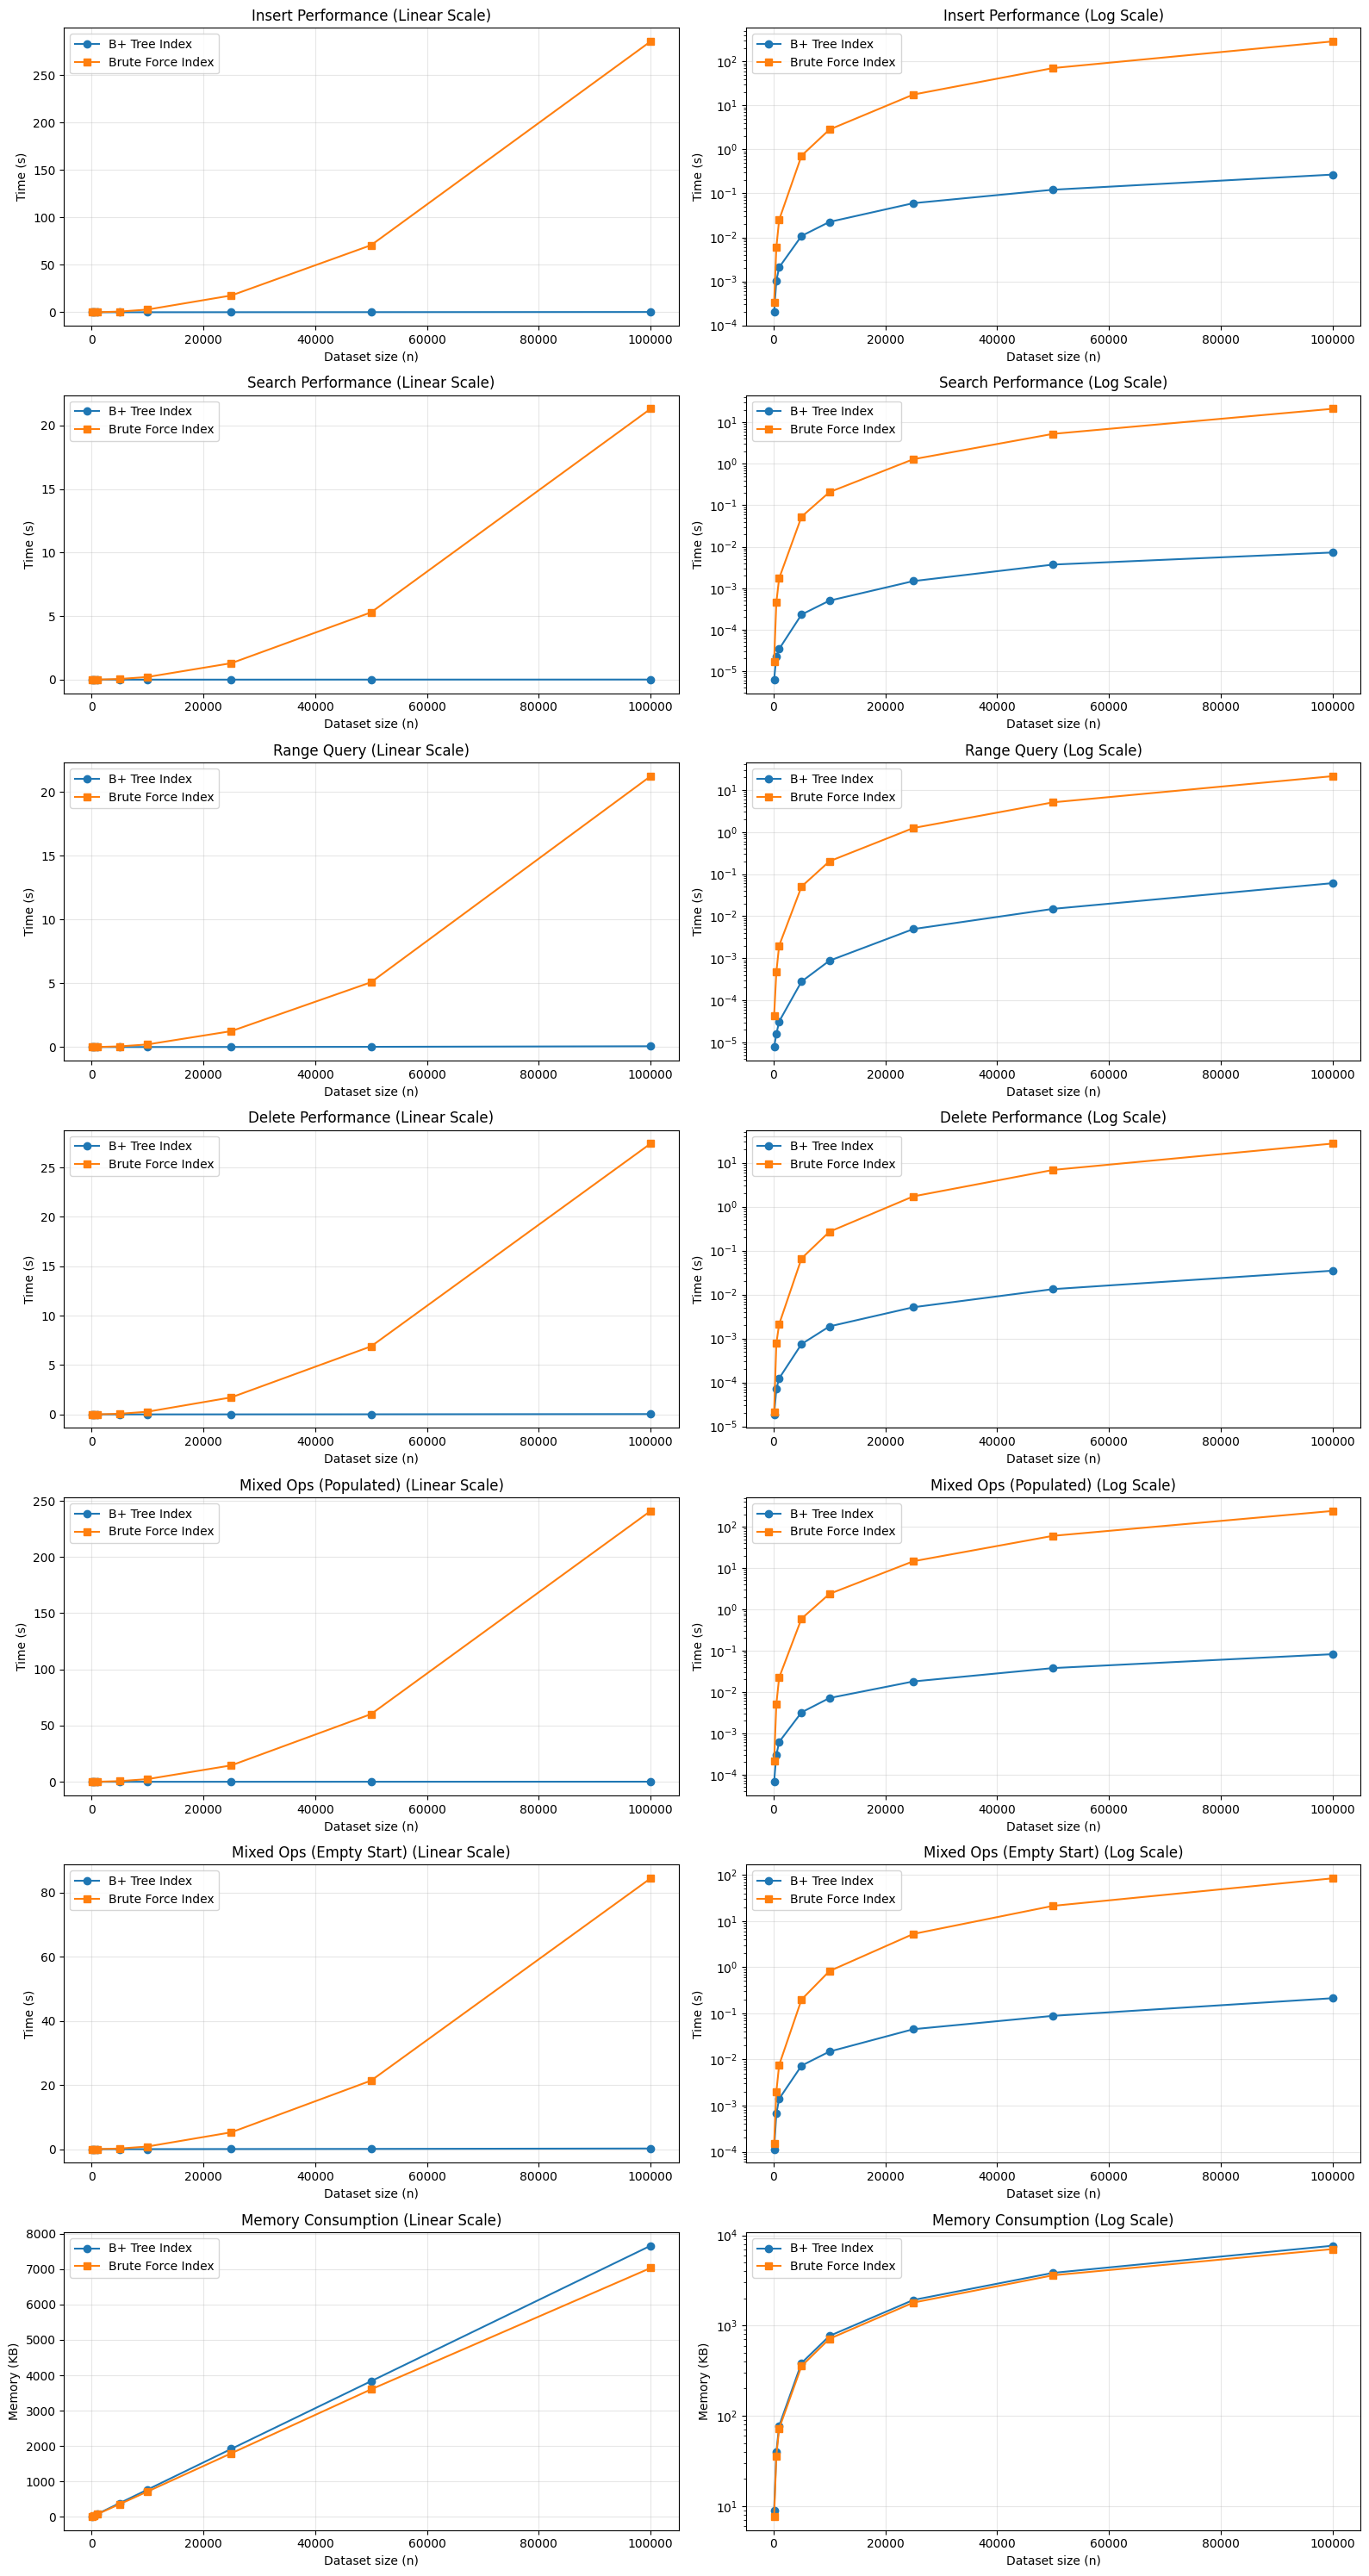

In [4]:
if __name__ == "__main__":
    analyzer = PerformanceAnalyzer(dataset_sizes=[100, 500, 1000,5000,10000,25000,50000,100000], trials=1)
    analyzer.run_all()

## Performance Analysis

### Observations
- For very small datasets, B+ Tree shows only slight improvement
- As dataset size increases, performance gap grows exponentially
- Search and mixed operations benefit the most from B+ Tree
- Range queries are significantly faster due to sorted leaf nodes
- Insert and delete operations scale much better than brute force
- Memory overhead remains low (~1.06x–1.16x)

---

### Key Results
At large dataset sizes (100,000 records):
- Search → ~2900x faster
- Range Query → ~350x faster
- Delete → ~780x faster
- Insert → ~1000x faster
- Mixed operations → ~2900x faster

This clearly demonstrates the scalability advantage of indexing.

---

### Why B+ Tree is Faster
- O(log n) operations vs O(n) linear scan
- High branching factor reduces tree height
- Sorted structure enables efficient range queries
- Balanced tree ensures consistent performance

---

### Memory Usage
- B+ Tree uses slightly more memory (~1.06x–1.16x)
- Overhead due to tree nodes and pointers
- Growth is linear and controlled
- Tradeoff is justified due to massive performance gains

## Discussion

The results highlight an important tradeoff:

| Approach      | Advantage              | Disadvantage            |
|--------------|----------------------|------------------------|
| B+ Tree      | Fast operations       | Slight memory overhead |
| Brute Force  | Simple implementation | Poor scalability       |

B+ Tree is clearly superior for large datasets.

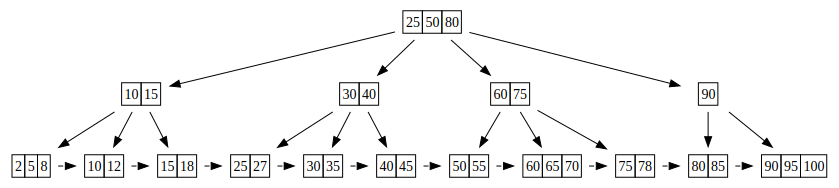

In [ ]:
# 1. Create the tree
from database.bplustree import BPlusTree
tree = BPlusTree(order=4)

keys_to_insert = [
    50, 25, 75, 10, 30, 60, 80, 5, 15, 27, 35, 55, 65, 
    78, 90, 2, 8, 12, 18, 40, 45, 70, 85, 95, 100
]
for key in keys_to_insert:
    tree.insert(key, f"Value_{key}")

# 3. Call the visualization method we just wrote
# tree.delete(90)
# # tree.delete(95)
# tree.insert(13,1)
# tree.insert(16,1)
# tree.insert(14,1)
# tree.insert(9,1)


dot = tree.visualize_tree()
dot


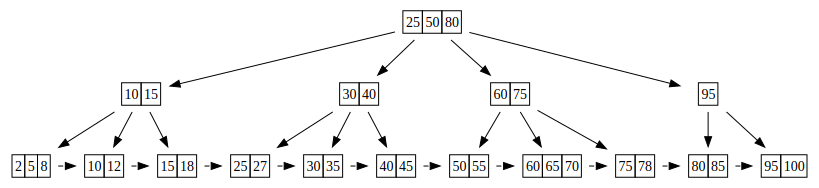

In [6]:
tree.delete(90)

dot = tree.visualize_tree()
dot

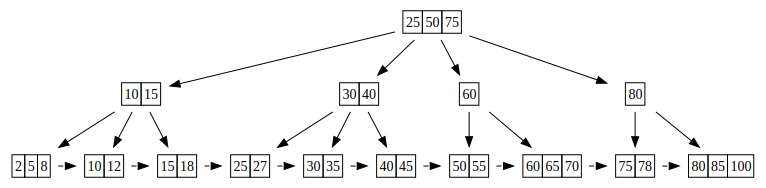

In [7]:
tree.delete(95)
dot = tree.visualize_tree()
dot

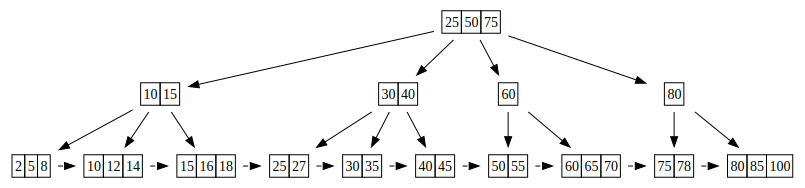

In [8]:
tree.insert(16,1)
tree.insert(14,1)
# tree.insert(9,1)


dot = tree.visualize_tree()
dot

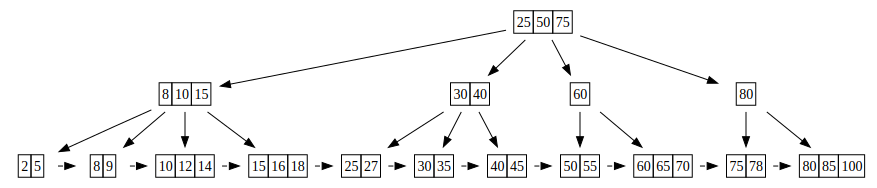

In [9]:
tree.insert(9,1)


dot = tree.visualize_tree()
dot

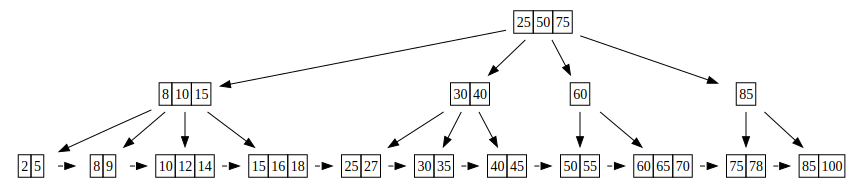

In [10]:
tree.delete(80)
dot = tree.visualize_tree()
dot

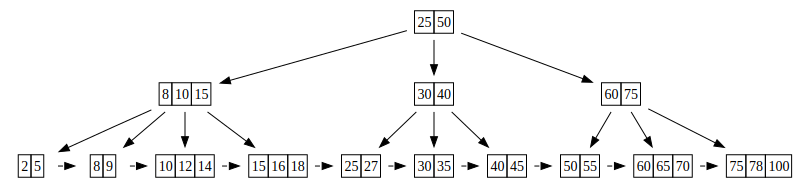

In [11]:
tree.delete(85)
dot = tree.visualize_tree()
dot

## Challenges Faced

- Implementing B+ Tree correctly (splits, merges, and balancing)
- Debugging tree structure and pointer errors
- Maintaining correct leaf node linkage for range queries
- Ensuring no duplicate keys and correct updates
- Keeping benchmarking fair across both approaches
- Handling variability in timing measurements
- Estimating memory usage accurately in Python

These challenges helped in understanding practical issues in database indexing.

## Conclusion

This project implemented a lightweight DBMS indexing engine and compared B+ Tree with brute force.

Key conclusions:
- B+ Tree significantly improves performance for large datasets
- Range queries benefit the most
- Memory overhead is minimal compared to speed gains

Thus, indexing is essential for scalable database systems.

## Future Work

Possible improvements:
- Increase number of trials for better accuracy
- Add statistical analysis (mean, variance)
- Test larger datasets
- Compare with hash indexing
- Optimize memory usage